# **Ejemplo PeriÓdicos**
ELABORADO POR: JORGE LUIS MAGAÑA PICHARDO\
Ejemplo:\
Un quiosquero vende periódicos a &euro; 1.10 c/u, Cada periódico le cuesta &euro; 0.90. Sus ventas se reflejan con la siguiete tabla

| PERIÓDICOS | **30** | **40** | **50** | **60** | **70** |
|------------|--------|--------|--------|--------|--------|
| f(x)       | 20%    | 25%    | 25%    | 20%    | 10%    |


Teniendo en cuenta un costo de &euro; 0.10 por el **reciclaje** de cada periodico no vendido, determine el beneficio promedio diario si pide 50 periódicos cada día.



**PASO 1**
***
Definir las variables\
**Variables**: número de ventas (aleatorio)


**PASO 2 y PASO 3**
***
Distribución de probabilidad

| PERIÓDICOS | **30** | **40** | **50** | **60** | **70** |
|------------|--------|--------|--------|--------|--------|
| f(x)       | 0.20   | 0.25   | 0.25   | 0.20   | 0.10   |
| F(x)       | 0.20   | 0.45   | 0.70   | 0.90   | 1.00   |


SI generamos un $X$ ~$ U(0,1)$\
**Ejemplo:**\
$X = 0.58 $ y esto se encuentra en el intervalo de $0.45, 0.7 $, quiere decir que se simula una venta de 50 periods, nuestro problema indica que el cliente pide 50 periódicos por día.


**PASO 4**
***
Analizamos el caso de ejemplo:\
El número aleatorio 0.58 simuló una venta de 50 periódicos:\
* Ganancia por venta = $0.20 \cdot 50 =$ &euro; $10$
* Pérdida por reciclaje = $0.10 \cdot 0 =$ &euro; $0$
* Ventas perdidas = $0.20 \cdot 00 =$ &euro; $0$

**MODELO**\
si **ventas simuladas** < **pedido**:\
ventas reales = **ventas simuladas**\
ventas perdidas = 0\
periódicos no vendidos = **pedido**-**ventas simuladas**



Si **ventas simuladas** > **pedido**:\
ventas reales = **pedido**\
ventas perdidas = **ventas simuladas** - **pedido**\
periódicos no vendidos = 0

Entonces, podemos calcular el beneficio así:

Beneficio = Precio unitario de venta(1.10) x ventas reales- Costo unitario de adquisición(0.90) x pedido - Costo unitario de reciclaje(0.10) x periódicos no vendidos

**PASO 5**
***

| DÍA  | **NÚMERO ALEATORIO** | **VENTAS REALES** | **50** | **60** | **70** |
|------|----------------------|-------------------|--------|--------|--------|
| f(x) | 0.20                 | 0.25              | 0.25   | 0.20   | 0.10   |
| F(x) | 0.20                 | 0.45              | 0.70   | 0.90   | 1.00   |

In [1]:
import numpy as np
import random as r
import matplotlib.pyplot as plt
from sympy.matrices.expressions import transpose


**Digitize**

Lo que hace digitize en mi código tomando los intervalos de [0, 0.2, 0.45, 0.7, 0.9, 1.01], si el número random está entre 0 y 0.2 me arrojará el índice 1, si el número aleatorio se encuentra por arriba de 0.2 y menor que el siguiente valor (0.45), me dará el índice 2 y asi sucesivamente hasta nuestro último elemento (en este caso) de la lista (el último índice será 5 en esta práctica), si llegáramos a obtener un valor menor que el primer elemento de la lista el índice será 0, en este caso no puede ocurrir porque las probabilidades están entre 0 y 1 y nuestro intervalo empieza en 0

In [2]:
def sim_ventas(x):
    ventas_prob= []
    ventas_sim =[]
    for i in range(x):
        ventas_prob.append(r.random())
    #Probabilidades del 0 a 1 dadas por el número random
    probs = [0, 0.2, 0.45, 0.70, 0.90, 1.01]
    # Clasificando con digitize,
    indices = np.digitize(ventas_prob, probs, right=False)
    digit = [1,2,3,4,5]
    #Ventas, haré una relación de las probabilidades con las ventas del problema en un diccionario
    ventas = [30,40,50,60,70]
    ventas_con_prob = dict(zip(digit, ventas))
    #Nuestras ventas simuladas de acuerdo a las "x" simulaciones que se usarán quedarán como:
    for i in indices:
        ventas_sim.append(ventas_con_prob[i])
    return  ventas_sim


Después de esta función, ya podemos simular ventas, aquí un ejemplo de las ventas que se simularon 100 veces

In [3]:
#De nuestra función tomamos el índice 3 que nos dá las ventas simuladas de acuerdo a la probabilidad
ventas_simulacion = sim_ventas(100)
print(ventas_simulacion)

[40, 50, 30, 40, 40, 30, 40, 70, 50, 40, 50, 40, 30, 30, 70, 30, 40, 60, 40, 50, 60, 30, 50, 50, 50, 30, 50, 40, 30, 30, 50, 50, 60, 60, 40, 60, 30, 30, 40, 50, 40, 40, 40, 30, 60, 50, 50, 60, 40, 50, 60, 30, 40, 50, 50, 40, 40, 30, 70, 70, 40, 40, 30, 30, 50, 40, 60, 60, 50, 50, 30, 40, 30, 60, 40, 30, 50, 60, 30, 60, 50, 50, 40, 30, 40, 60, 30, 50, 30, 60, 60, 40, 50, 60, 50, 60, 70, 30, 40, 40]


Ahora calcularé el beneficio promedio de las ventas que simulamos, de acuerdo a nuestro criterio del paso 4

In [4]:
def beneficio(x):
    pedido = 50
    beneficios = [ ]
    benef_prom =[ ]
    ventas_simuladas = sim_ventas(x)
    for i in range(len(ventas_simuladas)):
             if ventas_simuladas[i] <= pedido:
                 benef = (ventas_simuladas[i])*1.10 - pedido*0.90  - (pedido -  ventas_simuladas[i])*0.10
                 beneficios.append(benef)
                 benef_prom.append(np.mean(beneficios))
                 #print(beneficios)
                 plt.plot(benef_prom, color = 'blue')
             else:
                benef = pedido*1.10 -pedido*0.90
                beneficios.append(benef)
                benef_prom.append(np.mean(beneficios))
                #print(beneficios)
                plt.plot(benef_prom, color = 'blue')

    return np.mean(benef_prom)



**PASO 6**
Aquí realizaré 1000 iteraciones, que simulan ventas distintas y aleatorias para calcular el promedio esperado calculado en el código anterior

np.float64(2.12716044444016)

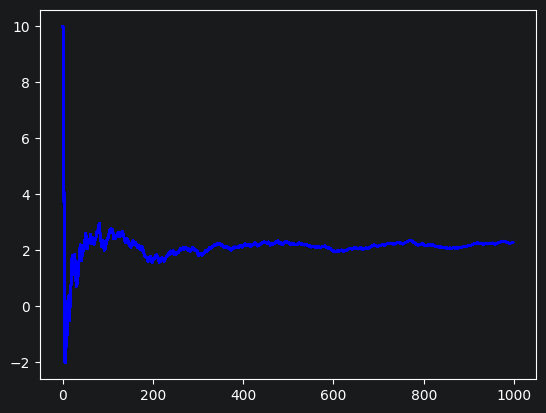

In [5]:
beneficio(1000)


Por lo tanto, notamos que es suficiente con usar alrededor de 700 pruebas para obbtener el beneficio promedio que está dado por:

el beneficio promedio por el vendedor con 50 pedidos es de 2.39
Su gráfica de acuerdo al promedio de beneficios obtenidos es:


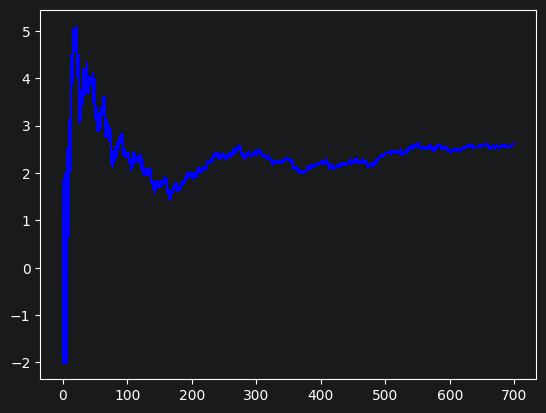

In [8]:
V = beneficio(700)
print(f'el beneficio promedio por el vendedor con 50 pedidos es de {V:.2f}\n'
      f'Su gráfica de acuerdo al promedio de beneficios obtenidos es:')